[INFO] Found Config at: /home/ak/Science/magneto/p/scripts
[INFO] Config imported successfully
Preparing visualization...
[INFO] Loading real flags from sif_aggregated.feather...
Rendering maps...


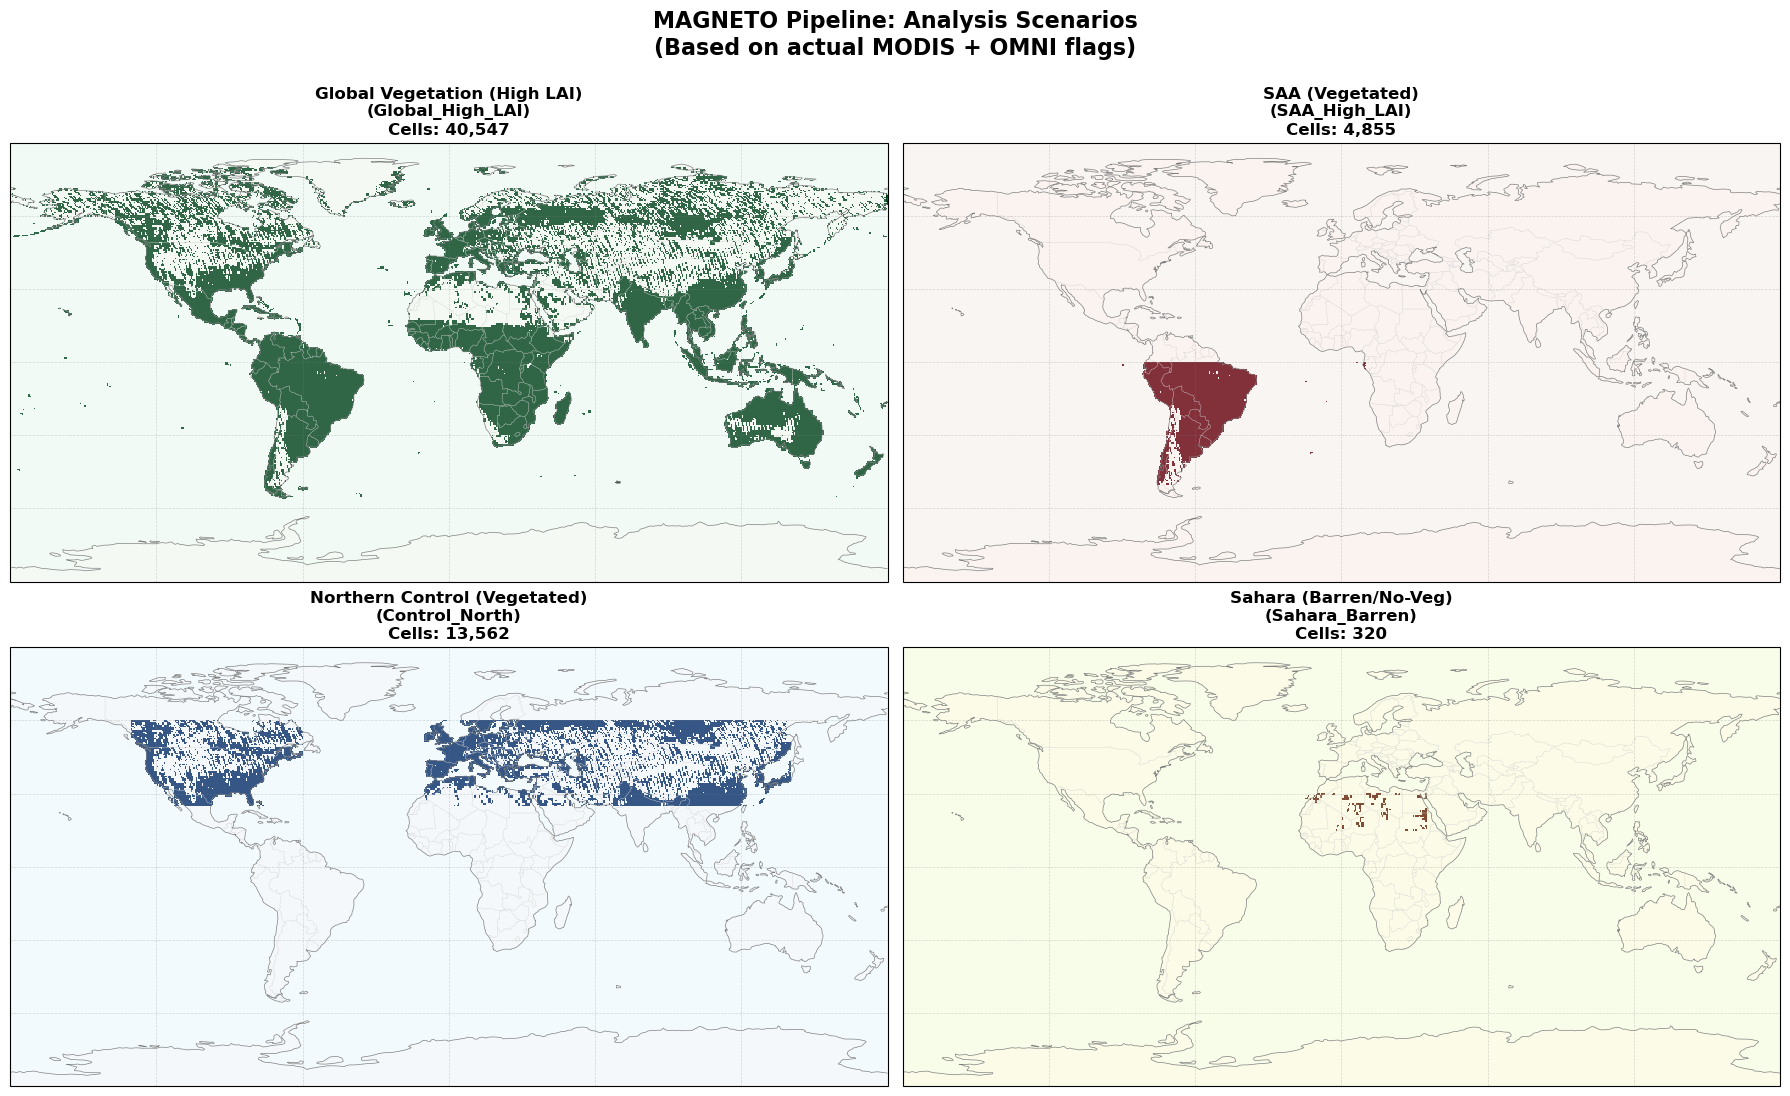


Scenario Statistics (0.5° Grid Cells):
Scenario                    Grid Cells   % of Global Grid
------------------------------------------------------------
Global_High_LAI                 40,547             15.58%
SAA_High_LAI                     4,855              1.87%
Control_North                   13,562              5.21%
Sahara_Barren                      320              0.12%


In [4]:
"""
Scenario Maps Visualization for OMNI2-SIF Pipeline

This script visualizes the actual data-driven scenarios defined in _Common.py:
1. Global_High_LAI (Global Vegetation)
2. SAA_High_LAI (South Atlantic Anomaly - Vegetated)
3. Control_North (Stable Northern Regions - Vegetated)
4. Sahara_Barren (Desert Control - Non-vegetated)

It reads the actual 'region_flags' from the processed dataset to ensure accuracy.
Fix: Solves 'facecolor will have no effect' warning by using edgecolor for lines.
"""

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pyarrow.feather as feather
from pathlib import Path
import warnings

# Suppress other minor warnings
warnings.filterwarnings("ignore")

# Get current directory for Jupyter compatibility
current_dir = Path.cwd()

# Try multiple paths to find the Config module
possible_paths = [
    current_dir.parent / 'scripts',
    current_dir / 'scripts',
    Path('..') / 'scripts',
]

for path in possible_paths:
    if (path / '_Common.py').exists():
        sys.path.insert(0, str(path))
        print(f"[INFO] Found Config at: {path}")
        break
else:
    print("[ERROR] Could not find _Common.py")
    exit()

try:
    from _Common import Config, RegionFlag
    print("[INFO] Config imported successfully")
except ImportError:
    print("[ERROR] Failed to load Config")
    exit()


def load_real_flags():
    """
    Loads region flags from the actual processed dataset.
    Returns lat, lon arrays and the corresponding flags.
    """
    flag_file = Config.FILE_SIF_FINAL  # data/interim/sif_aggregated.feather
    
    if not flag_file.exists():
        print(f"[WARN] Data file {flag_file} not found.")
        print("       Cannot visualize dynamic flags (LAI). Using static boxes only.")
        return None

    print(f"[INFO] Loading real flags from {flag_file.name}...")
    # Load only unique grid cells (lat, lon, flags) to save memory
    df = feather.read_feather(flag_file, columns=['lat_id', 'lon_id', 'region_flags'])
    df = df.drop_duplicates()
    
    # Decode IDs back to coordinates
    df['latitude'] = df['lat_id'] / 100.0
    df['longitude'] = df['lon_id'] / 100.0
    
    return df


def grid_data(df, resolution=0.5):
    """
    Maps the sparse DataFrame points to a dense grid for pcolormesh.
    """
    lats = np.arange(-90, 90 + resolution, resolution)
    lons = np.arange(-180, 180 + resolution, resolution)
    
    # Create empty grid
    flags_grid = np.zeros((len(lats), len(lons)), dtype=int)
    
    # Map coordinates to grid indices
    lat_idx = ((df['latitude'].values + 90) / resolution).astype(int)
    lon_idx = ((df['longitude'].values + 180) / resolution).astype(int)
    
    # Clip indices to be safe
    lat_idx = np.clip(lat_idx, 0, len(lats) - 1)
    lon_idx = np.clip(lon_idx, 0, len(lons) - 1)
    
    # Fill grid
    flags_grid[lat_idx, lon_idx] = df['region_flags'].values
    
    return lons, lats, flags_grid


def create_scenario_maps():
    """
    Main function to visualize Scenarios defined in Config.
    """
    print("Preparing visualization...")
    
    # 1. Load Data
    df_flags = load_real_flags()
    
    if df_flags is not None:
        lons, lats, flags_grid = grid_data(df_flags, resolution=0.5)
        has_real_data = True
    else:
        # Fallback: Create dummy grid if no data exists
        lats = np.arange(-90, 90.5, 0.5)
        lons = np.arange(-180, 180.5, 0.5)
        flags_grid = np.zeros((len(lats), len(lons)), dtype=int)
        has_real_data = False

    # 2. Define Scenarios to Plot
    scenarios = list(Config.SCENARIO_MASKS.keys())
    
    # Define aesthetics for each scenario
    styles = {
        'Global_High_LAI': {'cmap': 'Greens', 'title': 'Global Vegetation (High LAI)'},
        'SAA_High_LAI':    {'cmap': 'Reds',   'title': 'SAA (Vegetated)'},
        'Control_North':   {'cmap': 'Blues',  'title': 'Northern Control (Vegetated)'},
        'Sahara_Barren':   {'cmap': 'YlOrBr', 'title': 'Sahara (Barren/No-Veg)'}
    }

    # 3. Plotting
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12),
                            subplot_kw={'projection': ccrs.PlateCarree()})
    axes = axes.flatten()
    
    print("Rendering maps...")
    
    for idx, sc_name in enumerate(scenarios):
        if idx >= len(axes): break
        ax = axes[idx]
        
        style = styles.get(sc_name, {'cmap': 'Purples', 'title': sc_name})
        
        if has_real_data:
            mask = Config.scenario_mask(flags_grid, sc_name).astype(float)
        else:
            mask = np.zeros_like(flags_grid, dtype=float)

        # Plot Data
        im = ax.pcolormesh(lon_grid, lat_grid, mask,
                          transform=ccrs.PlateCarree(),
                          cmap=style['cmap'],
                          vmin=0, vmax=1,
                          shading='auto',
                          alpha=0.8)
        
        # Plot Geographic Features (FIXED: explicit edgecolor/facecolor)
        ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
        ax.add_feature(cfeature.OCEAN, facecolor='#e0f7fa')
        
        # Lines: Use edgecolor instead of color to avoid "facecolor" warnings
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='gray', facecolor='none')
        ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='lightgray', facecolor='none')
        
        # Stats
        n_cells = np.sum(mask > 0)
        
        ax.set_title(f"{style['title']}\n({sc_name})\nCells: {n_cells:,}", 
                    fontsize=12, fontweight='bold')
        ax.set_global()
        ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.3, linestyle='--')

    plt.suptitle('MAGNETO Pipeline: Analysis Scenarios\n(Based on actual MODIS + OMNI flags)', 
                fontsize=16, fontweight='bold', y=0.95)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    # 4. Print Text Stats
    print("\nScenario Statistics (0.5° Grid Cells):")
    print("=" * 60)
    print(f"{'Scenario':<25} {'Grid Cells':>12} {'% of Global Grid':>18}")
    print("-" * 60)
    
    total_grid_points = flags_grid.size
    
    for sc_name in scenarios:
        if has_real_data:
            mask = Config.scenario_mask(flags_grid, sc_name)
            count = np.sum(mask)
        else:
            count = 0
            
        pct = (count / total_grid_points) * 100
        print(f"{sc_name:<25} {count:>12,} {pct:>17.2f}%")
    
    print("=" * 60)


if __name__ == "__main__":
    create_scenario_maps()